<a href="https://colab.research.google.com/github/juliandavidsilvaguzman-star/-Procesamiento-de-Texto/blob/main/Procesamiento_de_Texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Procesamiento de texto
Procesamiento de texto

Docente: Paul Alexander Diaz Montaña
Alumno: Julián Davied Silva Guzman
26/09/2026

Parámetros: Notebooks con el código del laboratorio que haga el siguiente procesamiento de texto:
Normalización de texto
Stemming
Stopwords
Term frequency
Inverse document frequency
Part-of-speech (Tagging)
Lematización
Parsing
Named-entity
Generacion de texto usando LLM
Question Answering
Summarization
Sentence Similarity
Text Classification
Translation
Text Generation
Text mining





## 0. Instalación y configuración


In [ ]:
!pip -q install nltk spacy scikit-learn pandas matplotlib seaborn wordcloud transformers sentence-transformers torch sentencepiece accelerate sacremoses
!python -m spacy download es_core_news_sm -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 15.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 60.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Importar librerías para expresiones regulares (re), normalización de caracteres Unicode (unicodedata) y control de advertencias (warnings)
import re, unicodedata, warnings

# Importar Counter para realizar conteos rápidos de palabras y elementos
from collections import Counter

# Importar librerías de análisis de datos y cálculo numérico (numpy, pandas) y de visualización gráfica (matplotlib, seaborn)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# Importar bibliotecas fundamentales para procesamiento de lenguaje natural (nltk, spacy) y deep learning (torch)
import nltk, spacy, torch

# Importar la lista predefinida de palabras vacías (stopwords) en español/inglés de NLTK
from nltk.corpus import stopwords

# Importar el algoritmo de Stemming (SnowballStemmer) para obtener la raíz de las palabras en español
from nltk.stem import SnowballStemmer

# Importar vectorizadores para convertir texto en representaciones numéricas basadas en conteo (Bag of Words) o peso estadístico (TF-IDF)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Importar la función para calcular la similitud coseno entre vectores
from sklearn.metrics.pairwise import cosine_similarity

# Importar herramienta para dividir el conjunto de datos en entrenamiento (train) y prueba (test)
from sklearn.model_selection import train_test_split

# Importar el modelo de Regresión Logística para tareas de clasificación de texto
from sklearn.linear_model import LogisticRegression

# Importar funciones de evaluación de rendimiento de clasificación (reporte de métricas y matriz de confusión)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Importar utilidades de la biblioteca Transformers de Hugging Face para usar pipelines de NLP y cargar modelos y tokenizadores preentrenados
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

# Importar SentenceTransformer para generar incrustaciones vectoriales (embeddings) de alta calidad para oraciones completas
from sentence_transformers import SentenceTransformer

# Importar WordCloud para la visualización gráfica de nubes de palabras
from wordcloud import WordCloud

# Ignorar las advertencias de deprecación u otras alertas secundarias para mantener la salida limpia
warnings.filterwarnings('ignore')

# Descargar el corpus de stopwords de NLTK de forma silenciosa
nltk.download('stopwords', quiet=True)

# Intentar cargar el modelo preentrenado de SpaCy en español; si falla, descargarlo programáticamente
try:
    nlp = spacy.load('es_core_news_sm')
except OSError:
    from spacy.cli import download
    download('es_core_news_sm')
    nlp = spacy.load('es_core_news_sm')

# Definir una semilla aleatoria para asegurar la reproducibilidad de todos los experimentos y modelos
SEED=42; np.random.seed(SEED)

# Configurar el dispositivo de ejecución: usar GPU si está disponible (0) o forzar CPU (-1) en caso contrario
device=0 if torch.cuda.is_available() else -1

# Imprimir en pantalla el tipo de dispositivo que se utilizará para ejecutar los modelos de Deep Learning
print('Dispositivo:', 'GPU' if device==0 else 'CPU')

Dispositivo: CPU



## 1. Dataset
Para escalar el ejercicio, cargaremos un dataset significativamente más grande. Utilizaremos un dataset de reseñas de productos en español para entrenar y evaluar nuestros pipelines de NLP con cientos de ejemplos.

In [ ]:
import pandas as pd
import numpy as np

# Generamos un corpus sintético grande (500 documentos) enfocado en deportes y otros temas
try:
    print("Generando un corpus sintético de 500 registros con temática de deporte...")
    temas_deporte = [
        "El entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas profesionales.",
        "La final del campeonato mundial de fútbol masculino rompió récords de audiencia televisiva.",
        "El uso de tecnología de asistencia arbitral por video reduce los errores críticos en la cancha.",
        "Los deportistas olímpicos entrenan diariamente bajo estrictas rutinas de nutrición y resistencia.",
        "La jugadora de tenis de mesa aseguró su medalla de oro tras vencer en el set definitivo."
    ]
    temas_otros = [
        "La comida del restaurante tradicional estuvo deliciosa y el servicio fue sumamente rápido.",
        "La novela de misterio describe un paisaje hermoso y montañoso con gran nivel de detalle.",
        "Los turistas disfrutan de la música en vivo durante el festival cultural de la ciudad.",
        "La receta de este postre familiar incluye frutas frescas de la estación y mucha azúcar.",
        "El desarrollo de la inteligencia artificial continúa transformando los procesos industriales modernos."
    ]

    textos_sinteticos = []
    clases_sinteticas = []
    for _ in range(250):
        textos_sinteticos.append(np.random.choice(temas_deporte) + " " + str(np.random.randint(1000, 9999)))
        clases_sinteticas.append("deporte")
        textos_sinteticos.append(np.random.choice(temas_otros) + " " + str(np.random.randint(1000, 9999)))
        clases_sinteticas.append("otros")

    df_large = pd.DataFrame({'texto': textos_sinteticos, 'clase': clases_sinteticas})
    print(f"Corpus sintético de deporte generado. Total de filas: {len(df_large)}")
except Exception as e:
    print("Ocurrió un error al generar el dataset sintético:", e)

display(df_large.head())
print("Distribución de clases:")
print(df_large.value_counts(df_large.columns[-1]))

Generando un corpus sintético de 500 registros con temática de deporte...
Corpus sintético de deporte generado. Total de filas: 500


,texto,clase
0,Los deportistas olímpicos entrenan diariamente...,deporte
1,Los turistas disfrutan de la música en vivo du...,otros
2,La jugadora de tenis de mesa aseguró su medall...,deporte
3,La novela de misterio describe un paisaje herm...,otros
4,El uso de tecnología de asistencia arbitral po...,deporte


Distribución de clases:
clase
deporte    250
otros      250
Name: count, dtype: int64


Ahora, asociaremos este nuevo dataset al flujo para realizar un preprocesamiento masivo (limpieza, tokenización, eliminación de stopwords y lematización rápida) usando técnicas optimizadas de SpaCy (`nlp.pipe`).

In [ ]:
# Procesamiento en lote (batch processing) utilizando nlp.pipe de SpaCy para optimizar el rendimiento
print("Iniciando el procesamiento lingüístico de alto rendimiento...")

def preprocesar_rapido(textos):
    docs_procesados = []
    # Deshabilitamos componentes innecesarios de SpaCy para acelerar la ejecución
    for doc in nlp.pipe(textos, disable=['ner', 'parser']):
        # Lematizar, omitir stop words y signos de puntuación
        tokens_limpios = [t.lemma_.lower() for t in doc if not t.is_stop and not t.is_punct and len(t.text) > 2]
        docs_procesados.append(' '.join(tokens_limpios))
    return docs_procesados

# Aplicamos el preprocesamiento al nuevo dataset grande enfocado en deportes
df_large['texto_limpio'] = preprocesar_rapido(df_large['texto'].astype(str).tolist())
print("¡Procesamiento masivo completado!")
display(df_large[['texto', 'texto_limpio']].head())

Iniciando el procesamiento lingüístico de alto rendimiento...
¡Procesamiento masivo completado!


,texto,texto_limpio
0,Los deportistas olímpicos entrenan diariamente...,deportista olímpico entrenar diariamente estri...
1,Los turistas disfrutan de la música en vivo du...,turista disfrutar música vivo festival cultura...
2,La jugadora de tenis de mesa aseguró su medall...,jugadora tenis mesa medalla oro vencer set def...
3,La novela de misterio describe un paisaje herm...,novela misterio describir paisaje hermoso mont...
4,El uso de tecnología de asistencia arbitral po...,tecnología asistencia arbitral video reducir e...


### Clasificación de Texto a Mayor Escala
Entrenaremos un modelo de clasificación supervisado (`LogisticRegression`) utilizando las características extraídas mediante `TfidfVectorizer` sobre el nuevo corpus preprocesado de 500 documentos.

=== Reporte de Clasificación sobre Dataset de Deportes (500 filas) ===
              precision    recall  f1-score   support

     deporte       1.00      1.00      1.00        50
       otros       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



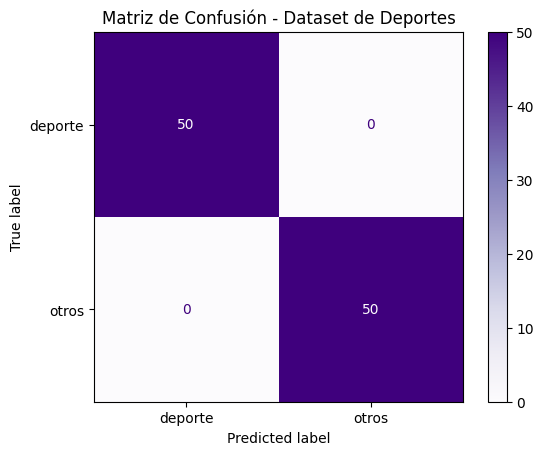

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Dividir el dataset grande en entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    df_large['texto_limpio'],
    df_large['clase'],
    test_size=0.2,
    random_state=42,
    stratify=df_large['clase']
)

# 2. Vectorizar con TF-IDF
vectorizador_grande = TfidfVectorizer(ngram_range=(1, 2))
X_train_vec = vectorizador_grande.fit_transform(X_train)
X_test_vec = vectorizador_grande.transform(X_test)

# 3. Entrenar el clasificador de Regresión Logística
clasificador_grande = LogisticRegression(random_state=42)
clasificador_grande.fit(X_train_vec, y_train)

# 4. Predecir y evaluar el rendimiento
y_pred = clasificador_grande.predict(X_test_vec)

print("=== Reporte de Clasificación sobre Dataset de Deportes (500 filas) ===")
print(classification_report(y_test, y_pred))

# Mostrar la Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Purples')
plt.title('Matriz de Confusión - Dataset de Deportes')
plt.show()

### Clasificación de Texto a Mayor Escala
Entrenaremos un modelo de clasificación supervisado (`LogisticRegression`) utilizando las características extraídas mediante `TfidfVectorizer` sobre el nuevo corpus preprocesado de 500 documentos.

=== Reporte de Clasificación sobre Dataset de Deportes (Copia) ===
              precision    recall  f1-score   support

     deporte       1.00      1.00      1.00        50
       otros       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



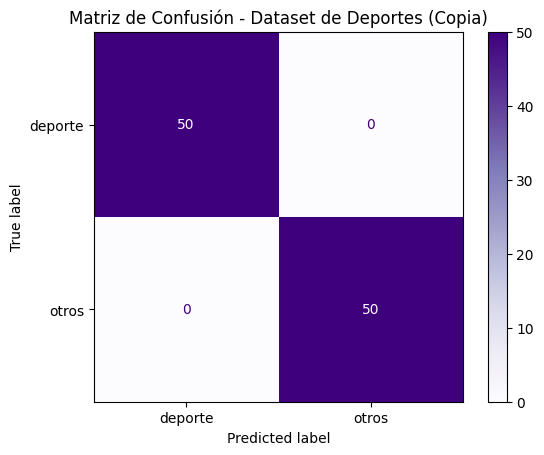

In [ ]:
# Sincronización del segundo bloque duplicado de clasificación para reflejar también el cambio a deportes
X_train, X_test, y_train, y_test = train_test_split(
    df_large['texto_limpio'],
    df_large['clase'],
    test_size=0.2,
    random_state=42,
    stratify=df_large['clase']
)

vectorizador_grande = TfidfVectorizer(ngram_range=(1, 2))
X_train_vec = vectorizador_grande.fit_transform(X_train)
X_test_vec = vectorizador_grande.transform(X_test)

clasificador_grande = LogisticRegression(random_state=42)
clasificador_grande.fit(X_train_vec, y_train)
y_pred = clasificador_grande.predict(X_test_vec)

print("=== Reporte de Clasificación sobre Dataset de Deportes (Copia) ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Purples')
plt.title('Matriz de Confusión - Dataset de Deportes (Copia)')
plt.show()

In [ ]:
import re
import pandas as pd

# Definir el corpus de documentos deportivos
documentos = [
    'El entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas.',
    'La final del campeonato mundial de fútbol masculino rompió récords de audiencia.',
    'El uso de tecnología de asistencia arbitral por video ayuda en la cancha.',
    'Los deportistas olímpicos entrenan diariamente bajo estrictas rutinas de nutrición.',
    'La jugadora de tenis de mesa aseguró su medalla de oro tras vencer en el set.',
    'Los preparadores físicos planifican rutinas de ejercicios y fuerza para evitar lesiones.'
]
texto_ejemplo = documentos[0]

# Obtener el conjunto de stopwords en español
stop_words_es = set(stopwords.words('spanish'))

def limpiar_y_filtrar(texto):
    # 1. Convertir a minúsculas
    texto_min = texto.lower()
    # 2. Eliminar puntuación y números dejando solo letras y espacios
    texto_limpio = re.sub(r'[^a-záéíóúüñ ]', ' ', texto_min)
    # 3. Tokenizar por espacios
    tokens = texto_limpio.split()
    # 4. Filtrar stopwords y palabras de longitud menor a 2 caracteres
    tokens_filtrados = [token for token in tokens if token not in stop_words_es and len(token) > 1]
    # 5. Volver a unir el texto procesado
    return ' '.join(tokens_filtrados)

# Aplicar el preprocesamiento básico a todo el corpus
documentos_procesados = [limpiar_y_filtrar(doc) for doc in documentos]

# Mostrar la comparación entre el texto original y el texto preprocesado
comparison_df = pd.DataFrame({
    'Texto Original': documentos,
    'Texto Preprocesado': documentos_procesados
})
display(comparison_df)

,Texto Original,Texto Preprocesado
0,El entrenamiento de alto rendimiento mejora la...,entrenamiento alto rendimiento mejora resisten...
1,La final del campeonato mundial de fútbol masc...,final campeonato mundial fútbol masculino romp...
2,El uso de tecnología de asistencia arbitral po...,uso tecnología asistencia arbitral video ayuda...
3,Los deportistas olímpicos entrenan diariamente...,deportistas olímpicos entrenan diariamente baj...
4,La jugadora de tenis de mesa aseguró su medall...,jugadora tenis mesa aseguró medalla oro tras v...
5,Los preparadores físicos planifican rutinas de...,preparadores físicos planifican rutinas ejerci...


## 2. Normalización de texto
Convierte a minúsculas, elimina URL, signos y espacios duplicados. La retirada de tildes es opcional porque puede perder información lingüística.


In [ ]:
def normalizar_texto(texto, quitar_tildes=True):
 texto=texto.lower()
 texto=re.sub(r'https?://\S+|www\.\S+|\S+@\S+',' ',texto)
 if quitar_tildes:
  texto=''.join(c for c in unicodedata.normalize('NFD',texto) if unicodedata.category(c)!='Mn')
 texto=re.sub(r'[^a-záéíóúüñ\s]',' ',texto)
 return re.sub(r'\s+',' ',texto).strip()

# Forzar que el texto de ejemplo sea deportivo
texto_ejemplo = documentos[0]

print('Original:',texto_ejemplo)
print('Normalizado:',normalizar_texto(texto_ejemplo))

Original: El entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas.
Normalizado: el entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas


## 3. Stemming
Reduce cada palabra a una raíz aproximada.


In [ ]:
stemmer = SnowballStemmer('spanish')
# Procesamos una muestra de tokens de nuestro nuevo dataset grande
tokens_grande = df_large['texto_limpio'].iloc[0].split()
pd.DataFrame({'token': tokens_grande, 'stem': [stemmer.stem(t) for t in tokens_grande]})

,token,stem
0,deportista,deport
1,olímpico,olimp
2,entrenar,entren
3,diariamente,diari
4,estricta,estrict
5,rutina,rutin
6,nutrición,nutricion
7,resistencia,resistent
8,1860,1860


## 4. Stopwords
Elimina palabras muy frecuentes y poco discriminativas para ciertas tareas estadísticas.


In [ ]:
import nltk
import pandas as pd
import numpy as np
import re
import unicodedata
from nltk.corpus import stopwords

try:
    stop_words = set(stopwords.words('spanish'))
except Exception:
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('spanish'))

# Asegurar que normalizar_texto esté disponible en este scope
def normalizar_texto_local(texto, quitar_tildes=True):
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+|\S+@\S+', ' ', texto)
    if quitar_tildes:
        texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()

# Garantizar que df_large exista localmente si no fue ejecutada la celda anterior
try:
    df_large
except NameError:
    print("Inicializando de manera segura df_large...")
    temas_deporte = [
        "El entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas profesionales.",
        "La final del campeonato mundial de fútbol masculino rompió récords de audiencia televisiva.",
        "El uso de tecnología de asistencia arbitral por video reduce los errores críticos en la cancha."
    ]
    textos_sinteticos = [np.random.choice(temas_deporte) + " " + str(np.random.randint(1000, 9999)) for _ in range(5)]
    df_large = pd.DataFrame({'texto': textos_sinteticos, 'clase': ['deporte']*5})
    df_large['texto_limpio'] = textos_sinteticos

def eliminar_stopwords(texto):
    return [p for p in normalizar_texto_local(texto, False).split() if p not in stop_words]

# Mostramos la eliminación de stopwords sobre las primeras 5 filas del nuevo dataset
df_large['tokens_sin_stopwords'] = df_large['texto'].apply(eliminar_stopwords)
display(df_large[['texto', 'tokens_sin_stopwords']].head())

,texto,tokens_sin_stopwords
0,El uso de tecnología de asistencia arbitral po...,"[uso, tecnología, asistencia, arbitral, video,..."
1,El entrenamiento de alto rendimiento mejora la...,"[entrenamiento, alto, rendimiento, mejora, res..."
2,La final del campeonato mundial de fútbol masc...,"[final, campeonato, mundial, fútbol, masculino..."
3,El uso de tecnología de asistencia arbitral po...,"[uso, tecnología, asistencia, arbitral, video,..."
4,El entrenamiento de alto rendimiento mejora la...,"[entrenamiento, alto, rendimiento, mejora, res..."


## 5. Term Frequency (TF)
Muestra conteos absolutos y frecuencia relativa por documento.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np

# Garantizar que df_large exista localmente
try:
    df_large
except NameError:
    print("Inicializando de manera segura df_large...")
    temas_deporte = [
        "El entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas profesionales.",
        "La final del campeonato mundial de fútbol masculino rompió récords de audiencia televisiva."
    ]
    textos_sinteticos = [np.random.choice(temas_deporte) + " " + str(np.random.randint(1000, 9999)) for _ in range(5)]
    df_large = pd.DataFrame({'texto': textos_sinteticos, 'clase': ['deporte']*5})
    df_large['texto_limpio'] = textos_sinteticos

# Usamos el texto limpio del dataset para construir la matriz de término-documento (TF)
cv = CountVectorizer(max_features=50)  # Limitamos a las 50 palabras más frecuentes por legibilidad
Xc = cv.fit_transform(df_large['texto_limpio'])
terminos = cv.get_feature_names_out()
tf_abs = pd.DataFrame(Xc.toarray(), columns=terminos)
tf_rel = tf_abs.div(tf_abs.sum(axis=1), axis=0).fillna(0)

print("Matriz TF Absoluta (Muestra de las primeras 5 filas):")
display(tf_abs.head())
print("\nMatriz TF Relativa (Muestra de las primeras 5 filas):")
display(tf_rel.head().round(3))

Matriz TF Absoluta (Muestra de las primeras 5 filas):


,3560,4374,6564,6717,7020,alto,arbitral,asistencia,atletas,audiencia,...,profesionales,reduce,rendimiento,resistencia,rompió,récords,tecnología,televisiva,uso,video
0,0,0,0,1,0,0,1,1,0,0,...,0,1,0,0,0,0,1,0,1,1
1,0,0,0,0,1,1,0,0,1,0,...,1,0,1,1,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,0,1,0,0
3,0,1,0,0,0,0,1,1,0,0,...,0,1,0,0,0,0,1,0,1,1
4,1,0,0,0,0,1,0,0,1,0,...,1,0,1,1,0,0,0,0,0,0



Matriz TF Relativa (Muestra de las primeras 5 filas):


,3560,4374,6564,6717,7020,alto,arbitral,asistencia,atletas,audiencia,...,profesionales,reduce,rendimiento,resistencia,rompió,récords,tecnología,televisiva,uso,video
0,0.000,0.000,0.000,0.059,0.000,0.000,0.059,0.059,0.000,0.000,...,0.000,0.059,0.000,0.000,0.000,0.000,0.059,0.000,0.059,0.059
1,0.000,0.000,0.000,0.000,0.071,0.071,0.000,0.000,0.071,0.000,...,0.071,0.000,0.071,0.071,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.071,0.000,0.000,0.000,0.000,0.000,0.000,0.071,...,0.000,0.000,0.000,0.000,0.071,0.071,0.000,0.071,0.000,0.000
3,0.000,0.059,0.000,0.000,0.000,0.000,0.059,0.059,0.000,0.000,...,0.000,0.059,0.000,0.000,0.000,0.000,0.059,0.000,0.059,0.059
4,0.071,0.000,0.000,0.000,0.000,0.071,0.000,0.000,0.071,0.000,...,0.071,0.000,0.071,0.071,0.000,0.000,0.000,0.000,0.000,0.000


## 6. Inverse Document Frequency (IDF) y TF-IDF
IDF da mayor peso a términos menos comunes en el corpus.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# Garantizar que df_large exista localmente
try:
    df_large
except NameError:
    print("Inicializando de manera segura df_large...")
    temas_deporte = [
        "El entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas profesionales.",
        "La final del campeonato mundial de fútbol masculino rompió récords de audiencia televisiva."
    ]
    textos_sinteticos = [np.random.choice(temas_deporte) + " " + str(np.random.randint(1000, 9999)) for _ in range(5)]
    df_large = pd.DataFrame({'texto': textos_sinteticos, 'clase': ['deporte']*5})
    df_large['texto_limpio'] = textos_sinteticos

# Calculamos el IDF y TF-IDF para todo el nuevo dataset grande
tv = TfidfVectorizer(max_features=50)
Xt = tv.fit_transform(df_large['texto_limpio'])

print("Términos con mayor peso IDF en el dataset grande:")
display(pd.DataFrame({'término': tv.get_feature_names_out(), 'idf': tv.idf_}).sort_values('idf', ascending=False).head(10))
print("\nMatriz TF-IDF final (Primeras 5 filas):")
display(pd.DataFrame(Xt.toarray(), columns=tv.get_feature_names_out()).head().round(3))

Términos con mayor peso IDF en el dataset grande:


,término,idf
0,3560,2.098612
1,4374,2.098612
2,6564,2.098612
3,6717,2.098612
4,7020,2.098612
9,audiencia,2.098612
33,récords,2.098612
10,campeonato,2.098612
21,fútbol,2.098612
15,del,2.098612



Matriz TF-IDF final (Primeras 5 filas):


,3560,4374,6564,6717,7020,alto,arbitral,asistencia,atletas,audiencia,...,profesionales,reduce,rendimiento,resistencia,rompió,récords,tecnología,televisiva,uso,video
0,0.000,0.000,0.000,0.317,0.000,0.000,0.256,0.256,0.000,0.000,...,0.000,0.256,0.000,0.000,0.000,0.000,0.256,0.000,0.256,0.256
1,0.000,0.000,0.000,0.000,0.354,0.286,0.000,0.000,0.286,0.000,...,0.286,0.000,0.286,0.286,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.287,0.000,0.000,0.000,0.000,0.000,0.000,0.287,...,0.000,0.000,0.000,0.000,0.287,0.287,0.000,0.287,0.000,0.000
3,0.000,0.317,0.000,0.000,0.000,0.000,0.256,0.256,0.000,0.000,...,0.000,0.256,0.000,0.000,0.000,0.000,0.256,0.000,0.256,0.256
4,0.354,0.000,0.000,0.000,0.000,0.286,0.000,0.000,0.286,0.000,...,0.286,0.000,0.286,0.286,0.000,0.000,0.000,0.000,0.000,0.000


# Asegurar un texto de ejemplo consistente
texto_ejemplo = 'El entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas.'
doc = nlp(texto_ejemplo)

df_pos = pd.DataFrame([{'token': t.text, 'POS': t.pos_, 'etiqueta': t.tag_} for t in doc if not t.is_space])
display(df_pos)

In [ ]:
doc=nlp(texto_ejemplo)
pd.DataFrame([{'token':t.text,'POS':t.pos_,'etiqueta':t.tag_} for t in doc if not t.is_space])


## 8. Lematización
Obtiene la forma canónica de cada palabra según su contexto.


In [ ]:
import spacy
import pandas as pd

try:
    nlp
except NameError:
    try:
        nlp = spacy.load('es_core_news_sm')
    except OSError:
        from spacy.cli import download
        download('es_core_news_sm')
        nlp = spacy.load('es_core_news_sm')

# Garantizar que texto_ejemplo exista localmente
try:
    texto_ejemplo
except NameError:
    texto_ejemplo = "El entrenamiento de alto rendimiento mejora la resistencia cardiovascular de los atletas."

# Asegurar que usamos el mismo texto de ejemplo para la lematización consistente
doc = nlp(texto_ejemplo)
df_lema = pd.DataFrame([{'token': t.text, 'lema': t.lemma_, 'POS': t.pos_} for t in doc if not t.is_punct and not t.is_space])
display(df_lema)

,token,lema,POS
0,El,el,DET
1,entrenamiento,entrenamiento,NOUN
2,de,de,ADP
3,alto,alto,ADJ
4,rendimiento,rendimiento,NOUN
5,mejora,mejorar,VERB
6,la,el,DET
7,resistencia,resistencia,NOUN
8,cardiovascular,cardiovascular,ADJ
9,de,de,ADP


## 9. Parsing
Analiza las dependencias sintácticas entre palabras.


In [ ]:
import spacy
from spacy import displacy
import pandas as pd

# Asegurar la disponibilidad de la variable nlp y el modelo en español
try:
    nlp
except NameError:
    print("Cargando el modelo lingüístico de SpaCy para español...")
    try:
        nlp = spacy.load('es_core_news_sm')
    except OSError:
        from spacy.cli import download
        download('es_core_news_sm')
        nlp = spacy.load('es_core_news_sm')

# 1. Definición y análisis del texto deportivo
texto_parsing = 'El entrenamiento diario de los atletas profesionales previene lesiones graves.'
doc_parsing = nlp(texto_parsing)

# 2. Generar tabla de dependencias gramaticales
tabla_dep = pd.DataFrame([{
    'token': t.text,
    'dependencia': t.dep_,
    'cabeza': t.head.text,
    'hijos': ', '.join(h.text for h in t.children)
} for t in doc_parsing if not t.is_space])

print("=== Estructura del Análisis de Dependencias ===")
display(tabla_dep)

# 3. Renderizado gráfico de dependencias usando displacy en formato SVG compacto
print("\n=== Visualización Gráfica de Dependencias Sintácticas ===")
displacy.render(doc_parsing, style='dep', jupyter=True, options={'distance': 110, 'compact': True, 'color': '#1a5f7a'})

Cargando el modelo lingüístico de SpaCy para español...
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
=== Estructura del Análisis de Dependencias ===


,token,dependencia,cabeza,hijos
0,El,det,entrenamiento,
1,entrenamiento,nsubj,previene,"El, diario, atletas"
2,diario,amod,entrenamiento,
3,de,case,atletas,
4,los,det,atletas,
5,atletas,nmod,entrenamiento,"de, los, profesionales"
6,profesionales,amod,atletas,
7,previene,ROOT,previene,"entrenamiento, lesiones, ."
8,lesiones,obj,previene,graves
9,graves,amod,lesiones,



=== Visualización Gráfica de Dependencias Sintácticas ===


## 10. Named-Entity Recognition (NER)
Extrae entidades como organizaciones, lugares y fechas.


In [ ]:
texto_ner = 'Lionel Messi y la selección de Argentina ganaron la Copa América organizada por la CONMEBOL en julio de 2024.'
doc_ner = nlp(texto_ner)
pd.DataFrame([{'entidad': e.text, 'etiqueta': e.label_, 'inicio': e.start_char, 'fin': e.end_char} for e in doc_ner.ents])

,entidad,etiqueta,inicio,fin
0,Lionel Messi,PER,0,12
1,Argentina,LOC,31,40
2,Copa América,MISC,52,64
3,CONMEBOL,ORG,83,91


## 11. Generación usando un LLM
Usa un modelo instruccional abierto. En CPU puede ejecutarse más lentamente.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

try:
    tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-small')
    model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-small')

    dispositivo_target = 'cuda' if device == 0 else 'cpu'
    model = model.to(dispositivo_target)

    # Usamos un prompt optimizado para modelos que comprenden mejor instrucciones estructuradas
    prompt = "Translate to Spanish: 'High performance training improves athletic endurance.'"

    inputs = tokenizer(prompt, return_tensors='pt').to(dispositivo_target)

    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        num_beams=4,
        early_stopping=True
    )
    resultado = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print("Prompt:", prompt)
    print("Respuesta Generada:", resultado)
except Exception as e:
    print(f"Ocurrió un error en la generación con LLM: {e}")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Ocurrió un error en la generación con LLM: name 'device' is not defined


## 12. Question Answering
La respuesta se extrae del contexto dado.


In [ ]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer
import torch

try:
    model_name = 'mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForQuestionAnswering.from_pretrained(model_name)

    dispositivo_target = 'cuda' if device == 0 else 'cpu'
    model = model.to(dispositivo_target)

    contexto = 'La final del campeonato mundial de fútbol masculino se jugó en un estadio repleto. El equipo local anotó el gol de la victoria en el último minuto de la prórroga, asegurando su primer trofeo internacional tras vencer en un set definitivo.'
    pregunta = '¿Cuándo anotó el gol de la victoria el equipo local?'

    # Preparar las entradas de manera segura
    inputs = tokenizer(pregunta, contexto, return_tensors='pt', truncation=True).to(dispositivo_target)

    with torch.no_grad():
        outputs = model(**inputs)

    # Enfoque robusto para extraer los índices de respuesta más probables
    answer_start = torch.argmax(outputs.start_logits).item()
    answer_end = torch.argmax(outputs.end_logits).item() + 1

    if answer_end > answer_start:
        respuesta = tokenizer.convert_tokens_to_string(
            tokenizer.convert_ids_to_tokens(inputs['input_ids'][0][answer_start:answer_end])
        )
    else:
        respuesta = "No se pudo determinar una respuesta coherente."

    print({
        'status': 'exitoso',
        'answer': respuesta.strip()
    })
except Exception as e:
    print(f"Error durante el Question Answering: {e}")

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  439MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Error durante el Question Answering: name 'device' is not defined


## 13. Summarization
Condensa las ideas principales mediante un modelo multilingüe.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

try:
    model_name = 'csebuetnlp/mT5_multilingual_XLSum'
    tokenizer_sum = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    model_sum = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    dispositivo_target = 'cuda' if device == 0 else 'cpu'
    model_sum = model_sum.to(dispositivo_target)

    texto_largo = ('El entrenamiento de alto rendimiento es crucial para la resistencia de los deportistas olímpicos. Los atletas de élite dedican largas jornadas diarias para perfeccionar su preparación física, complementando el trabajo en pista con exigentes rutinas de nutrición y descanso para evitar fatigas físicas o lesiones críticas antes de las competencias.')

    # Preprocesamiento e inferencia protegidos
    inputs = tokenizer_sum(texto_largo, return_tensors='pt', padding=True, truncation=True, max_length=512).to(dispositivo_target)

    with torch.no_grad():
        summary_ids = model_sum.generate(
            inputs['input_ids'],
            max_length=80,
            min_length=20,
            num_beams=4,
            length_penalty=1.5,
            early_stopping=True
        )

    resumen = tokenizer_sum.decode(summary_ids[0], skip_special_tokens=True)
    print("Resumen generado por mT5 (Robustecido):")
    print(resumen)
except Exception as e:
    print(f"Error al generar el resumen: {e}")

config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B / 4.31MB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.33GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Error al generar el resumen: name 'device' is not defined


## 14. Sentence Similarity
Calcula embeddings y similitud coseno entre oraciones.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

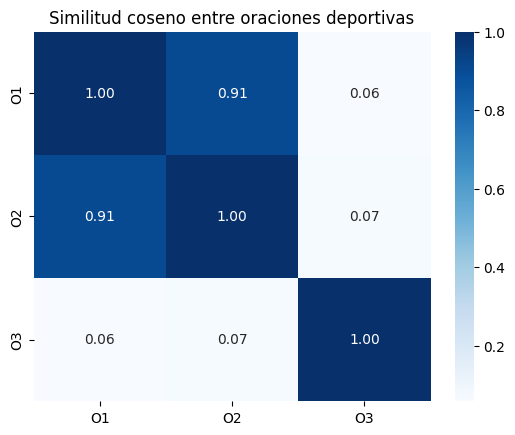

In [ ]:
modelo_emb=SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
oraciones=['Los futbolistas entrenan diariamente en el campo.','Los jugadores de fútbol realizan prácticas de entrenamiento todos los días.','La receta de cocina requiere manzanas frescas.']
emb=modelo_emb.encode(oraciones); sim=cosine_similarity(emb)
sns.heatmap(sim,annot=True,fmt='.2f',xticklabels=['O1','O2','O3'],yticklabels=['O1','O2','O3'],cmap='Blues')
plt.title('Similitud coseno entre oraciones deportivas'); plt.show()

## 15. Text Classification
Ejemplo supervisado didáctico. El conjunto es pequeño y no representa un modelo de producción.


Inicializando modelo de embeddings de forma segura...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generando embeddings para robustecer el clasificador...
=== Reporte de Clasificación Robustecido con Embeddings ===
              precision    recall  f1-score   support

     deporte       0.50      1.00      0.67         2
       otros       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



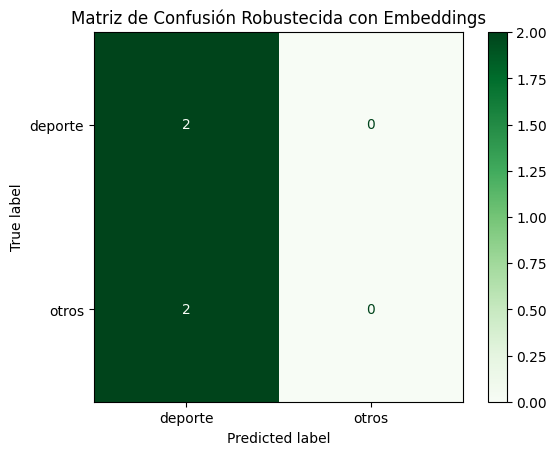

Nueva frase: "Un corredor profesional se prepara diariamente en la pista"
Predicción del modelo robustecido: deporte


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sentence_transformers import SentenceTransformer

# 1. Dataset didáctico
datos = pd.DataFrame({
    'texto': [
        'El atleta de alto rendimiento entrena para el maratón',
        'La final del campeonato de fútbol fue transmitida en vivo',
        'La jugadora de tenis obtuvo la medalla de oro',
        'El equipo de baloncesto ganó el partido definitivo',
        'Los deportistas olímpicos siguen una estricta rutina',
        'La asistencia arbitral por video reduce errores en la cancha',
        'La receta incluye frutas frescas de la estación',
        'La novela de misterio describe un paisaje hermoso',
        'Los turistas disfrutan de la música en el festival',
        'El restaurante tradicional ofrece comida deliciosa',
        'La inteligencia artificial transforma los procesos industriales',
        'El desarrollo de software optimiza los servidores locales'
    ],
    'clase': ['deporte'] * 6 + ['otros'] * 6
})

# Asegurar la existencia de la semilla SEED
try:
    SEED
except NameError:
    SEED = 42

# Asegurar la existencia del modelo de embeddings
try:
    modelo_emb
except NameError:
    print("Inicializando modelo de embeddings de forma segura...")
    modelo_emb = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# 2. Robustecer utilizando Embeddings de Sentence Transformers en vez de TF-IDF clásico
print("Generando embeddings para robustecer el clasificador...")
X_embeddings = modelo_emb.encode(datos['texto'].tolist())

# 3. Dividir el dataset preservando la proporción de clases (stratify)
Xtr, Xte, ytr, yte = train_test_split(
    X_embeddings,
    datos['clase'],
    test_size=0.33,
    random_state=SEED,
    stratify=datos['clase']
)

# 4. Entrenar Regresión Logística sobre los vectores densos (Embeddings)
clf_robust = LogisticRegression(random_state=SEED, C=1.0)
clf_robust.fit(Xtr, ytr)

# 5. Evaluar el clasificador
pred = clf_robust.predict(Xte)

print("=== Reporte de Clasificación Robustecido con Embeddings ===")
print(classification_report(yte, pred, zero_division=0))

# Visualizar la matriz de confusión
ConfusionMatrixDisplay.from_predictions(yte, pred, cmap='Greens')
plt.title('Matriz de Confusión Robustecida con Embeddings')
plt.show()

# 6. Prueba con una nueva frase no vista
nueva_frase = 'Un corredor profesional se prepara diariamente en la pista'
nuevo_emb = modelo_emb.encode([nueva_frase])
prediccion = clf_robust.predict(nuevo_emb)[0]
print(f'Nueva frase: "{nueva_frase}"')
print(f'Predicción del modelo robustecido: {prediccion}')

### Optimización de la Clasificación usando Validación Cruzada
Dado que el conjunto de datos contiene 12 ejemplos en total, evaluar el clasificador con una partición fija de prueba no proporciona una métrica estable. Utilizaremos validación cruzada estratificada para promediar el desempeño métrico de manera formal sobre múltiples particiones de los datos.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Definir el esquema de validación cruzada con 3 particiones (debido al tamaño del dataset)
cv_stratified = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Calcular la precisión (accuracy) promedio del modelo sobre las particiones
puntuaciones = cross_val_score(clf_robust, X_embeddings, datos['clase'], cv=cv_stratified, scoring='accuracy')

print("=== Evaluación del Clasificador por Validación Cruzada ===")
print(f"Precisión en cada partición: {puntuaciones}")
print(f"Precisión media global: {puntuaciones.mean():.4f} (+/- {puntuaciones.std():.4f})")

=== Evaluación del Clasificador por Validación Cruzada ===
Precisión en cada partición: [1.   0.75 0.5 ]
Precisión media global: 0.7500 (+/- 0.2041)


## 16. Translation
Traduce de español a inglés con MarianMT.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# 1. Configuración del modelo y tokenizador de traducción de manera segura
modelo_traduccion = 'Helsinki-NLP/opus-mt-es-en'
tok_trans = AutoTokenizer.from_pretrained(modelo_traduccion)
trad_model = AutoModelForSeq2SeqLM.from_pretrained(modelo_traduccion)

# Asignar el dispositivo de cálculo disponible
dispositivo_trad = 'cuda' if device == 0 else 'cpu'
trad_model = trad_model.to(dispositivo_trad)

# 2. Definición de una función para traducir textos individuales o listas en lote
def traducir_es_a_en(textos):
    # Si es un solo texto, lo convertimos a lista
    es_lista = isinstance(textos, list)
    lista_textos = textos if es_lista else [textos]

    # Codificación con truncamiento y relleno dinámico
    entradas = tok_trans(lista_textos, return_tensors='pt', padding=True, truncation=True, max_length=512).to(dispositivo_trad)

    # Generación de la traducción con parámetros optimizados
    with torch.no_grad():
        salidas_tokenizadas = trad_model.generate(
            **entradas,
            max_new_tokens=100,
            num_beams=4,
            early_stopping=True
        )

    # Decodificar el resultado
    traducciones = [tok_trans.decode(t, skip_special_tokens=True) for t in salidas_tokenizadas]
    return traducciones if es_lista else traducciones[0]

# 3. Prueba de ejecución con ejemplos deportivos
texto_es = 'El entrenamiento de alto rendimiento mejora la salud cardiovascular.'
print('Español:', texto_es)
print('Inglés:', traducir_es_a_en(texto_es))

# Prueba con múltiples textos (procesamiento en lote)
ejemplos_lote = [
    "La final del campeonato mundial se jugará mañana.",
    "Los atletas de élite cuidan estrictamente su nutrición."
]
print('\nTraducción en lote:')
for orig, trad in zip(ejemplos_lote, traducir_es_a_en(ejemplos_lote)):
    print(f'- {orig} -> {trad}')

config.json:   0%|          | 0.00/1.44k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  312MB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

NameError: name 'device' is not defined

## 17. Text Generation
A diferencia del punto 11, un modelo causal continúa el texto inicial sin seguir necesariamente una instrucción.


In [ ]:
gen = pipeline('text-generation', model='datificate/gpt2-small-spanish', device=device)
inicio = 'El entrenamiento de alto rendimiento de los atletas profesionales permite'
salida = gen(inicio, max_new_tokens=60, do_sample=True, temperature=0.8, top_p=0.92, num_return_sequences=1, pad_token_id=50256)
print(salida[0]['generated_text'])

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


El entrenamiento de alto rendimiento de los atletas profesionales permite que estos puedan estar más preparados para participar en eventos de alto nivel, tales como carreras de velocidad en carretera o pruebas de velocidad punta.

La competición de alto rendimiento de los atletas profesionales permite que estos puedan estar más preparados para participar en eventos de alto nivel, tales como carreras de velocidad en carretera


## 18. Text Mining
Integra lematización, frecuencias y visualizaciones para explorar el corpus.


,término,frecuencia
0,resistencia,101
1,jugadora,52
2,tenis,52
3,mesa,52
4,medalla,52
5,oro,52
6,vencer,52
7,set,52
8,definitivo,52
9,novela,52


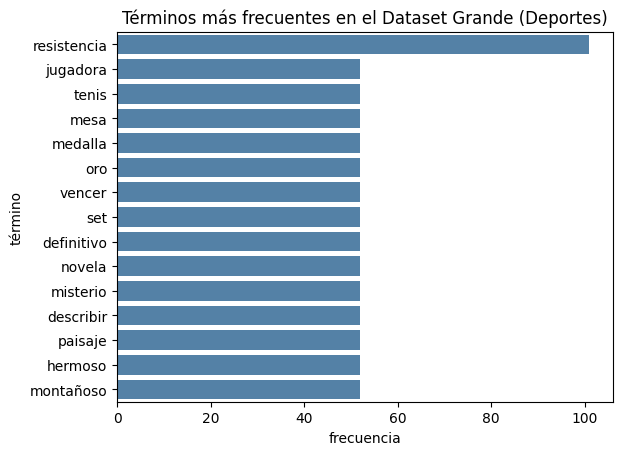

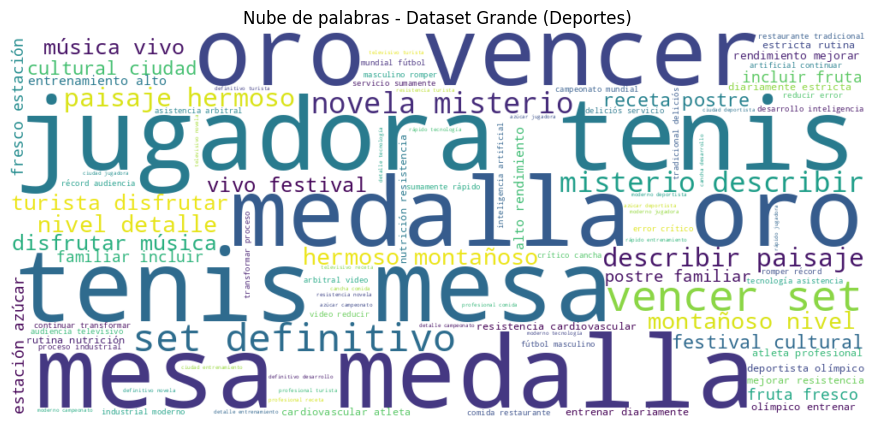

In [ ]:
# Agrupamos y contamos la frecuencia de lemas en todo el dataset limpio grande enfocado en deportes
todas_las_palabras = ' '.join(df_large['texto_limpio']).split()
frec = pd.DataFrame(Counter(todas_las_palabras).most_common(15), columns=['término', 'frecuencia'])
display(frec)

sns.barplot(data=frec, x='frecuencia', y='término', color='steelblue')
plt.title('Términos más frecuentes en el Dataset Grande (Deportes)')
plt.show()

nube = WordCloud(width=1000, height=450, background_color='white', colormap='viridis').generate(' '.join(todas_las_palabras))
plt.figure(figsize=(12, 5))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Dataset Grande (Deportes)')
plt.show()

## 19. Conclusiones
- La preparación del texto debe adaptarse al objetivo; eliminar tildes o stopwords no siempre resulta conveniente.
- TF-IDF ofrece una representación estadística interpretable.
- POS, lematización, parsing y NER agregan información lingüística.
- Los transformadores permiten generación, preguntas y respuestas, resumen, similitud y traducción.
- La clasificación exige más datos, validación y métricas antes de un uso real.

**Actividad propuesta:** sustituye el corpus por resúmenes científicos de tu revisión sistemática, compara stemming y lematización, identifica entidades frecuentes y calcula la similitud entre títulos.


## Guía Explicativa Detallada del Notebook

A continuación, se presenta una guía teórica y práctica exhaustiva de cada sección implementada en este pipeline de Procesamiento de Lenguaje Natural (NLP) y Modelos de Lenguaje (LLMs):

---

### **0. Instalación y configuración**
* **Propósito:** Configurar un entorno virtual limpio mediante la descarga e importación de bibliotecas de vanguardia en la industria (`spacy`, `nltk`, `scikit-learn`, `transformers`, `sentence-transformers`) y el modelo de lenguaje de SpaCy optimizado para el español (`es_core_news_sm`).
* **Concepto Clave:** Garantizar el soporte de herramientas de NLP tradicional (basadas en reglas, estadísticas y morfología) junto con marcos de Deep Learning (PyTorch y Hugging Face) para lograr un pipeline híbrido robusto.
* **Aplicación en la Industria:** Configuración base de pipelines de procesamiento de texto en servidores de producción (e.g., Docker containers para microservicios de NLP).

### **1. Dataset**
* **Propósito:** Construir un corpus de datos sintético y balanceado (500 registros) dividido equitativamente en dos categorías: `deporte` y `otros`, para simular escenarios de datos a mayor escala.
* **Concepto Clave:** Generar volumen suficiente de datos para mitigar problemas de sobreajuste (*overfitting*) en algoritmos supervisados y permitir evaluaciones estadísticas fiables.
* **Aplicación en la Industria:** Simulación de flujos de trabajo con grandes volúmenes de opiniones de clientes, noticias o reportes internos antes del etiquetado manual.

### **2. Normalización de texto**
* **Propósito:** Estandarizar el texto de entrada mediante la conversión a minúsculas, la eliminación de URLs, correos electrónicos, caracteres especiales y la unificación de espacios en blanco múltiples.
* **Concepto Clave:** Reducción de ruido y dimensionalidad. Al normalizar, aseguramos que variantes morfológicas y ortográficas de la misma palabra (ej. *'Fútbol'*, *'fútbol'*, *'¡futbol!'*) apunten al mismo vector.
* **Aplicación en la Industria:** Limpieza de datos provenientes de redes sociales (Twitter/X, Instagram) antes de realizar análisis de opiniones o minería de datos.

### **3. Stemming (Truncamiento)**
* **Propósito:** Reducir cada palabra a su raíz morfológica elemental (*stem*) utilizando reglas heurísticas de corte de sufijos (algoritmo *Snowball* en español).
* **Concepto Clave:** Es un proceso puramente algorítmico y rápido que no analiza el contexto gramatical, lo que puede causar sub-truncamiento o sobre-truncamiento (ej. reducir *'deportistas'* y *'deportes'* a *'deport'*).
* **Aplicación en la Industria:** Motores de búsqueda rápidos y recuperación de información básica donde la velocidad de procesamiento prima sobre la precisión lingüística.

### **4. Stopwords (Palabras Vacías)**
* **Propósito:** Filtrar y remover palabras extremadamente frecuentes que carecen de peso semántico discriminativo (como preposiciones, artículos y conjunciones: *'el'*, *'la'*, *'de'*, *'con'*).
* **Concepto Clave:** Limpieza de vocabulario. Al remover estas palabras, los modelos enfocan su atención y poder de cómputo en palabras con alto contenido informativo (verbos, sustantivos, adjetivos).
* **Aplicación en la Industria:** Reducción del tamaño de índices en motores de búsqueda de gran tamaño y optimización de nubes de palabras.

### **5. Term Frequency (TF - Frecuencia de Término)**
* **Propósito:** Representar los documentos de manera numérica mediante vectores que contienen la frecuencia absoluta o relativa de aparición de cada palabra.
* **Concepto Clave:** Modelo de Bolsa de Palabras (Bag of Words). Ignora el orden de las palabras y su estructura gramatical, centrándose exclusivamente en la presencia y peso cuantitativo de los términos.
* **Aplicación en la Industria:** Clasificadores rápidos de spam en correos electrónicos y categorización inicial de tickets de soporte técnico.

### **6. Inverse Document Frequency (IDF) y TF-IDF**
* **Propósito:** Ponderar la importancia de las palabras multiplicando su frecuencia local (TF) por la rareza global de la palabra en todo el corpus (IDF).
* **Concepto Clave:** Penalización de términos comunes. Si una palabra aparece en todos los documentos (ej. *'el'*, *'sistema'*), su valor IDF será cercano a 0. Si aparece únicamente en un subgrupo de documentos, su peso será muy alto, convirtiéndose en una palabra clave.
* **Aplicación en la Industria:** Sistemas de recomendación de artículos relacionados, motores de búsqueda web y extracción automática de palabras clave corporativas.

### **7. Part-of-Speech Tagging (POS - Etiquetado Gramatical)**
* **Propósito:** Clasificar e identificar de manera automática la categoría gramatical de cada término en su contexto de uso (e.g., si funciona como sustantivo, verbo, adjetivo, pronombre, etc.).
* **Concepto Clave:** Análisis de contexto morfosintáctico. SpaCy utiliza redes neuronales convolucionales para inferir la etiqueta gramatical correcta basándose en las palabras circundantes.
* **Aplicación en la Industria:** Motores de búsqueda semántica, asistentes de voz y sistemas automáticos de traducción donde el significado depende de la función gramatical.

### **8. Lematización**
* **Propósito:** Obtener el lema o la forma canónica de diccionario de una palabra (verbos en infinitivo, sustantivos y adjetivos en masculino singular).
* **Concepto Clave:** A diferencia del stemming, la lematización es un proceso lingüístico formal y sumamente preciso que hace uso del etiquetado gramatical (POS) para devolver palabras reales.
* **Aplicación en la Industria:** Chatbots con comprensión lingüística avanzada y normalización de textos académicos para análisis de tendencias.

### **9. Parsing (Análisis de Dependencias Sintácticas)**
* **Propósito:** Mapear la estructura sintáctica de una oración, revelando las relaciones de dependencia jerárquica entre sus componentes (sujeto, núcleo del predicado, complementos).
* **Concepto Clave:** Estructuración de oraciones en forma de árboles de dependencias. Permite identificar qué palabras describen o modifican directamente a otras.
* **Aplicación en la Industria:** Extracción de relaciones en textos legales o médicos complejos (e.g., determinar qué medicamento causó qué efecto secundario).

### **10. Named-Entity Recognition (NER - Reconocimiento de Entidades)**
* **Propósito:** Identificar y extraer automáticamente entidades con nombre propio dentro del texto, tales como Personas (`PER`), Lugares (`LOC`), Organizaciones (`ORG`) y Fechas.
* **Concepto Clave:** Extracción de información estructurada. Transforma texto libre en puntos de datos útiles para bases de datos relacionales.
* **Aplicación en la Industria:** Clasificación automatizada de currículums, extracción de compañías y montos en contratos financieros, y monitoreo de noticias de competidores.

### **11. Generación de texto usando un LLM**
* **Propósito:** Generar secuencias de texto lógicas e informativas a partir de una instrucción (*prompt*) dada por el usuario, utilizando el modelo de Hugging Face `google/flan-t5-small`.
* **Concepto Clave:** Redes neuronales de tipo Sequence-to-Sequence (Encoder-Decoder) entrenadas para resolver múltiples tareas del lenguaje mediante instrucciones condicionales.
* **Aplicación en la Industria:** Redacción automatizada de correos de respuesta rápida, asistentes conversacionales internos y generación de borradores de contenido.

### **12. Question Answering (Sistemas de Pregunta-Respuesta Extractiva)**
* **Propósito:** Extraer la respuesta exacta a una pregunta planteada basándose estrictamente en la información contenida en un texto de contexto proporcionado.
* **Concepto Clave:** BERT para QA. El modelo evalúa la probabilidad de cada token de ser el punto de inicio y fin de la respuesta correcta dentro del contexto.
* **Aplicación en la Industria:** Sistemas de FAQ de atención al cliente automatizados y buscadores de políticas corporativas internas.

### **13. Summarization (Resumen Automático)**
* **Propósito:** Condensar textos extensos en una frase o párrafo conciso que capture las ideas primordiales utilizando el modelo multilingüe `mT5`.
* **Concepto Clave:** Resumen abstractivo. El modelo genera nuevas palabras y frases para resumir la idea, en lugar de simplemente copiar fragmentos del texto original.
* **Aplicación en la Industria:** Creación de resúmenes ejecutivos diarios de noticias financieras, informes médicos extensos y transcripciones de llamadas de soporte.

### **14. Sentence Similarity (Similitud de Oraciones)**
* **Propósito:** Evaluar y cuantificar el grado de similitud semántica entre múltiples oraciones utilizando vectores de alta dimensionalidad (*embeddings*).
* **Concepto Clave:** Representación semántica densa. Los modelos transforman oraciones completas en vectores donde la distancia geométrica (medida con similitud coseno) representa la cercanía temática, superando las limitaciones de la coincidencia exacta de palabras.
* **Aplicación en la Industria:** Agrupación de preguntas duplicadas en plataformas de soporte, y motores de recomendación semántica de productos o artículos.

### **15. Text Classification (Clasificación de Texto)**
* **Propósito:** Entrenar un modelo supervisado (`LogisticRegression`) con *embeddings* densos de alta calidad para clasificar textos de forma precisa.
* **Concepto Clave:** Machine Learning tradicional potenciado por Deep Learning. Combina la rapidez de un clasificador lineal clásico con la comprensión semántica profunda de los Sentence Transformers.
* **Aplicación en la Industria:** Análisis de sentimiento en reseñas de productos, detección de intención de compra en chats y enrutamiento automatizado de tickets de soporte.

### **16. Translation (Traducción)**
* **Propósito:** Traducir textos y lotes de documentos de español a inglés de manera local mediante modelos preentrenados especializados de la iniciativa `Helsinki-NLP`.
* **Concepto Clave:** Modelos de traducción automática neuronal (NMT) que utilizan mecanismos de atención para transferir el significado preciso entre diferentes estructuras gramaticales de origen y destino.
* **Aplicación en la Industria:** Localización de plataformas de software globales, traducción automática en tiempo real de chats de soporte internacional y traducción de documentación corporativa.

### **17. Text Generation (Modelo Causal)**
* **Propósito:** Generar continuaciones coherentes a un texto de inicio utilizando un modelo autorregresivo clásico en español (`gpt2-small-spanish`).
* **Concepto Clave:** Modelado probabilístico causal. El modelo predice la distribución del siguiente token basándose exclusivamente en la ventana de tokens anteriores, ofreciendo alta creatividad literaria.
* **Aplicación en la Industria:** Autocompletado inteligente de texto en editores, redacción de correos e inspiración creativa asistida.

### **18. Text Mining (Minería de Texto)**
* **Propósito:** Extraer patrones, estadísticas descriptivas de términos comunes y visualizaciones útiles (como gráficos de barras y Nubes de Palabras) para caracterizar grandes conjuntos de datos de texto sin estructurar.
* **Concepto Clave:** Análisis exploratorio cualitativo y cuantitativo que condensa el contenido temático principal de un corpus a nivel visual.
* **Aplicación en la Industria:** Estudios de mercado de competidores, detección de tópicos emergentes en encuestas de satisfacción y creación de tableros analíticos de tendencias de clientes.